In [1]:
import csv
import logging
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Optional

logging.basicConfig(level=logging.WARNING, format='%(levelname)s: %(message)s')
log = logging.getLogger(__name__)

# Paths 
FORECAST_ROOT = Path('Data/Forecast')

# NWM column names 
COL_NWM_VERSION    = 'NWM_version_number'
COL_NWM_INIT_TIME  = 'model_initialization_time'
COL_NWM_VALID_TIME = 'model_output_valid_time'
COL_NWM_STREAMFLOW = 'streamflow_value'
COL_NWM_STREAM_ID  = 'streamID'
NWM_DATETIME_FMT   = '%Y-%m-%d_%H:%M:%S'

NWM_REQUIRED_COLS: frozenset[str] = frozenset({
    COL_NWM_VERSION, COL_NWM_INIT_TIME, COL_NWM_VALID_TIME,
    COL_NWM_STREAMFLOW, COL_NWM_STREAM_ID,
})

# USGS column names 
COL_USGS_DATETIME        = 'DateTime'
COL_USGS_FLOW            = 'USGSFlowValue'
COL_USGS_QUALITY         = '00060_cd'        
COL_USGS_QUALITY_LEGACY  = 'USGS_GageID'     


# Data structures 
@dataclass
class ForecastRow:
    """A single normalised forecast or observation record."""
    station_id:       Optional[str]
    source:           str                  
    forecast_init:    Optional[datetime]
    forecast_valid:   Optional[datetime]
    streamflow_value: Optional[float]
    nwm_version:      Optional[str]
    quality_code:     Optional[str]


# Parsing helpers 
def try_float(value: Optional[str]) -> Optional[float]:
    """Return *value* as a float, or None if blank/unparseable."""
    if not value:
        return None
    try:
        return float(value)
    except ValueError:
        return None


def parse_nwm_datetime(value: Optional[str]) -> Optional[datetime]:
    """Parse an NWM datetime string (``YYYY-MM-DD_HH:MM:SS``)."""
    if not value:
        return None
    try:
        return datetime.strptime(value, NWM_DATETIME_FMT)
    except ValueError:
        log.warning("Could not parse NWM datetime: %r", value)
        return None


def parse_usgs_datetime(value: Optional[str]) -> Optional[datetime]:
    """Parse a USGS datetime string, stripping timezone info when present."""
    if not value:
        return None
    try:
        dt = datetime.fromisoformat(value)
        return dt.replace(tzinfo=None)
    except ValueError:
        pass
    try:
        return datetime.strptime(value, '%Y-%m-%d %H:%M:%S%z').replace(tzinfo=None)
    except ValueError:
        log.warning("Could not parse USGS datetime: %r", value)
        return None


# CSV loading 
def _detect_format(headers: list[str]) -> str:
    """Return ``'NWM'``, ``'USGS'``, or ``'unknown'`` based on column headers."""
    header_set = set(headers)
    if NWM_REQUIRED_COLS.issubset(header_set):
        return 'NWM'
    if COL_USGS_DATETIME in header_set:
        return 'USGS'
    return 'unknown'


def _parse_nwm_row(raw: dict[str, str], station_id: str) -> ForecastRow:
    return ForecastRow(
        station_id=station_id,
        source='NWM',
        forecast_init=parse_nwm_datetime(raw.get(COL_NWM_INIT_TIME, '')),
        forecast_valid=parse_nwm_datetime(raw.get(COL_NWM_VALID_TIME, '')),
        streamflow_value=try_float(raw.get(COL_NWM_STREAMFLOW, '')),
        nwm_version=raw.get(COL_NWM_VERSION, ''),
        quality_code=None,
    )


def _parse_usgs_row(raw: dict[str, str], station_id: str) -> ForecastRow:
    ts = parse_usgs_datetime(raw.get(COL_USGS_DATETIME, ''))
    quality = raw.get(COL_USGS_QUALITY) or raw.get(COL_USGS_QUALITY_LEGACY, '')
    return ForecastRow(
        station_id=station_id,
        source='USGS',
        forecast_init=ts,
        forecast_valid=ts,
        streamflow_value=try_float(raw.get(COL_USGS_FLOW, '')),
        nwm_version=None,
        quality_code=quality,
    )


def read_forecast_csv(path: Path) -> list[ForecastRow]:
    """Read one forecast CSV and return its rows as :class:`ForecastRow` objects."""
    rows: list[ForecastRow] = []
    with path.open(newline='') as f:
        reader = csv.DictReader(f)
        if reader.fieldnames is None:
            log.warning("Empty or header-less file: %s", path.name)
            return rows

        headers = [h.strip() for h in reader.fieldnames]
        fmt = _detect_format(headers)
        if fmt == 'unknown':
            log.warning("Unrecognised format in %s — skipping", path.name)
            return rows

        # USGS station id is encoded in the filename as '<station_id>_*.csv'
        station_id = path.stem.split('_', 1)[0]

        for raw in reader:
            if fmt == 'NWM':
                rows.append(_parse_nwm_row(raw, station_id))
            else:
                rows.append(_parse_usgs_row(raw, station_id))

    return rows


def load_station_data(station_path: Path) -> list[ForecastRow]:
    """Load and time-sort all CSVs found directly under *station_path*."""
    rows: list[ForecastRow] = []
    for csv_file in sorted(station_path.glob('*.csv')):
        rows.extend(read_forecast_csv(csv_file))

    rows.sort(key=lambda r: (
        r.forecast_valid or datetime.min,
        r.forecast_init  or datetime.min,
    ))
    return rows


# Load all stations 
station_directories = sorted(p for p in FORECAST_ROOT.iterdir() if p.is_dir())
station_data: dict[str, list[ForecastRow]] = {
    d.name: load_station_data(d) for d in station_directories
}


In [2]:
@dataclass
class CleanSummary:
    """Per-station statistics after dropping rows with missing streamflow."""
    total_rows:   int
    cleaned_rows: int
    dropped_rows: int
    drop_rate:    float


def clean_station_data(
    raw: dict[str, list[ForecastRow]],
) -> tuple[dict[str, list[ForecastRow]], dict[str, CleanSummary]]:
    """Drop rows missing a streamflow value and return per-station summaries."""
    cleaned: dict[str, list[ForecastRow]] = {}
    summaries: dict[str, CleanSummary] = {}

    for station_name, rows in raw.items():
        valid    = [r for r in rows if r.streamflow_value is not None]
        dropped  = len(rows) - len(valid)
        cleaned[station_name]  = valid
        summaries[station_name] = CleanSummary(
            total_rows=len(rows),
            cleaned_rows=len(valid),
            dropped_rows=dropped,
            drop_rate=dropped / len(rows) if rows else 0.0,
        )

    return cleaned, summaries


cleaned_station_data, station_summaries = clean_station_data(station_data)

print('Cleaned summary by station:')
for station_name, s in station_summaries.items():
    print(
        f'  {station_name}: '
        f'total={s.total_rows}, '
        f'cleaned={s.cleaned_rows}, '
        f'dropped={s.dropped_rows} ({s.drop_rate:.1%})'
    )


Cleaned summary by station:
  20380357: total=396249, cleaned=396248, dropped=1 (0.0%)
  21609641: total=391658, cleaned=391643, dropped=15 (0.0%)


In [3]:
import pandas as pd
from dataclasses import asdict


def _quality_is_accepted(code: Optional[str]) -> bool:
    """Return False only when the USGS quality string contains the estimated flag 'e'."""
    if not code:
        return True   
    return 'e' not in code.split()


def align_station(rows: list[ForecastRow]) -> pd.DataFrame:
    """Join NWM forecasts to USGS observations for one station.

    Steps:
      1. Filter USGS rows to accepted quality codes (drop estimated 'e' readings).
      2. Resample USGS to hourly mean (USGS is 15-min; NWM is hourly).
      3. Compute NWM lead_hours = forecast_valid − forecast_init.
      4. Inner-join NWM rows to hourly USGS index on forecast_valid.

    Returns a DataFrame with columns:
        forecast_valid, forecast_init, nwm_streamflow,
        usgs_streamflow, lead_hours, station_id
    """
    df = pd.DataFrame([asdict(r) for r in rows])

    nwm  = df[df['source'] == 'NWM'].copy()
    usgs = df[df['source'] == 'USGS'].copy()

    if nwm.empty or usgs.empty:
        return pd.DataFrame()

    # USGS: quality filter → resample to hourly 
    usgs = usgs[usgs['quality_code'].apply(_quality_is_accepted)]
    if usgs.empty:
        return pd.DataFrame()

    usgs['forecast_valid'] = pd.to_datetime(usgs['forecast_valid'])
    usgs_hourly = (
        usgs.set_index('forecast_valid')['streamflow_value']
        .resample('1h').mean()
        .rename('usgs_streamflow')
        .dropna()
    )

    # NWM: compute lead time 
    nwm['forecast_valid'] = pd.to_datetime(nwm['forecast_valid'])
    nwm['forecast_init']  = pd.to_datetime(nwm['forecast_init'])
    nwm['lead_hours'] = (
        (nwm['forecast_valid'] - nwm['forecast_init'])
        .dt.total_seconds()
        .div(3600)
        .round()
        .astype(int)
    )
    nwm = nwm.rename(columns={'streamflow_value': 'nwm_streamflow'})

    # Inner join on forecast_valid timestamp 
    aligned = (
        nwm.set_index('forecast_valid')
        .join(usgs_hourly, how='inner')
        .reset_index()
    )

    keep = ['forecast_valid', 'forecast_init', 'nwm_streamflow',
            'usgs_streamflow', 'lead_hours', 'station_id']
    return aligned[keep].dropna()


aligned_data: dict[str, pd.DataFrame] = {}

for station_name, rows in cleaned_station_data.items():
    df = align_station(rows)
    if df.empty:
        print(f'{station_name}: no aligned pairs found')
        continue
    aligned_data[station_name] = df
    print(
        f'{station_name}: {len(df):,} aligned pairs  '
        f'lead_hours {df["lead_hours"].min()}–{df["lead_hours"].max()}  '
        f'({df["forecast_valid"].min().date()} → {df["forecast_valid"].max().date()})'
    )

print(f'\nTotal across all stations: {sum(len(v) for v in aligned_data.values()):,} paired rows')


20380357: 324,904 aligned pairs  lead_hours 1–18  (2021-04-21 → 2023-04-22)
21609641: 302,406 aligned pairs  lead_hours 1–18  (2021-04-21 → 2023-04-22)

Total across all stations: 627,310 paired rows


In [4]:
from sklearn.preprocessing import StandardScaler

# Season index: 0=winter, 1=spring, 2=summer, 3=autumn
SEASON_MAP: dict[int, int] = {
    12: 0,  1: 0,  2: 0,
     3: 1,  4: 1,  5: 1,
     6: 2,  7: 2,  8: 2,
     9: 3, 10: 3, 11: 3,
}

FEATURE_COLS = ['nwm_streamflow', 'lead_hours', 'hour_of_day', 'month', 'season']
TARGET_COL   = 'usgs_streamflow'


def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Append hour_of_day, month, and season columns derived from forecast_valid."""
    dt = pd.to_datetime(df['forecast_valid'])
    return df.assign(
        hour_of_day=dt.dt.hour,
        month=dt.dt.month,
        season=dt.dt.month.map(SEASON_MAP),
    )


scalers: dict[str, StandardScaler] = {}
featured_data: dict[str, pd.DataFrame] = {}

for station_name, df in aligned_data.items():
    df = add_temporal_features(df.copy())

    scaler = StandardScaler()
    df[['nwm_streamflow', TARGET_COL]] = scaler.fit_transform(
        df[['nwm_streamflow', TARGET_COL]]
    )
    scalers[station_name] = scaler
    featured_data[station_name] = df


In [5]:
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

splits: dict[str, dict] = {}

for station_name, df in featured_data.items():
    df = df.sort_values('forecast_valid').reset_index(drop=True)
    n      = len(df)
    i_val  = int(n * TRAIN_FRAC)
    i_test = int(n * (TRAIN_FRAC + VAL_FRAC))

    train = df.iloc[:i_val]
    val   = df.iloc[i_val:i_test]
    test  = df.iloc[i_test:]

    splits[station_name] = {
        'X_train': train[FEATURE_COLS].to_numpy(dtype=float),
        'y_train': train[TARGET_COL].to_numpy(dtype=float),
        'X_val':   val[FEATURE_COLS].to_numpy(dtype=float),
        'y_val':   val[TARGET_COL].to_numpy(dtype=float),
        'X_test':  test[FEATURE_COLS].to_numpy(dtype=float),
        'y_test':  test[TARGET_COL].to_numpy(dtype=float),
        'scaler':  scalers[station_name],
        'train_period': (train['forecast_valid'].min(), train['forecast_valid'].max()),
        'val_period':   (val['forecast_valid'].min(),   val['forecast_valid'].max()),
        'test_period':  (test['forecast_valid'].min(),  test['forecast_valid'].max()),
    }

    s = splits[station_name]
    print(f'{station_name}:')
    print(f'  train  {len(train):>7,} rows  {s["train_period"][0].date()} → {s["train_period"][1].date()}')
    print(f'  val    {len(val):>7,}  rows  {s["val_period"][0].date()} → {s["val_period"][1].date()}')
    print(f'  test   {len(test):>7,}  rows  {s["test_period"][0].date()} → {s["test_period"][1].date()}')


20380357:
  train  227,432 rows  2021-04-21 → 2022-09-15
  val     48,736  rows  2022-09-15 → 2023-01-03
  test    48,736  rows  2023-01-03 → 2023-04-22
21609641:
  train  211,684 rows  2021-04-21 → 2022-10-01
  val     45,361  rows  2022-10-01 → 2023-01-11
  test    45,361  rows  2023-01-11 → 2023-04-22


In [6]:
# Per-station feature-matrix summary
print('Feature / target summary by station:')
for station_name, s in splits.items():
    n_features = s['X_train'].shape[1]
    n_total    = s['X_train'].shape[0] + s['X_val'].shape[0] + s['X_test'].shape[0]
    print(
        f'  {station_name}: '
        f'features={n_features}, '
        f'total_rows={n_total:,}'
    )

print(f'\nFeature columns: {FEATURE_COLS}')
print(f'Target column:   {TARGET_COL}')


Feature / target summary by station:
  20380357: features=5, total_rows=324,904
  21609641: features=5, total_rows=302,406

Feature columns: ['nwm_streamflow', 'lead_hours', 'hour_of_day', 'month', 'season']
Target column:   usgs_streamflow


In [7]:
import numpy as np


for station_name, s in splits.items():
    for subset in ('X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test'):
        arr = s[subset]
        nan_count = np.isnan(arr).sum()
        inf_count = np.isinf(arr).sum()
        print(f'{station_name} {subset}: NaN={nan_count}, Inf={inf_count}')

        if nan_count > 0:
            print(f'  Replacing NaN values with 0...')
            s[subset] = np.nan_to_num(arr, nan=0.0)

        if inf_count > 0:
            print(f'  Replacing Inf values with 0...')
            s[subset] = np.nan_to_num(s[subset], posinf=0.0, neginf=0.0)

print('\nData quality check passed.')


20380357 X_train: NaN=0, Inf=0
20380357 X_val: NaN=0, Inf=0
20380357 X_test: NaN=0, Inf=0
20380357 y_train: NaN=0, Inf=0
20380357 y_val: NaN=0, Inf=0
20380357 y_test: NaN=0, Inf=0
21609641 X_train: NaN=0, Inf=0
21609641 X_val: NaN=0, Inf=0
21609641 X_test: NaN=0, Inf=0
21609641 y_train: NaN=0, Inf=0
21609641 y_val: NaN=0, Inf=0
21609641 y_test: NaN=0, Inf=0

Data quality check passed.


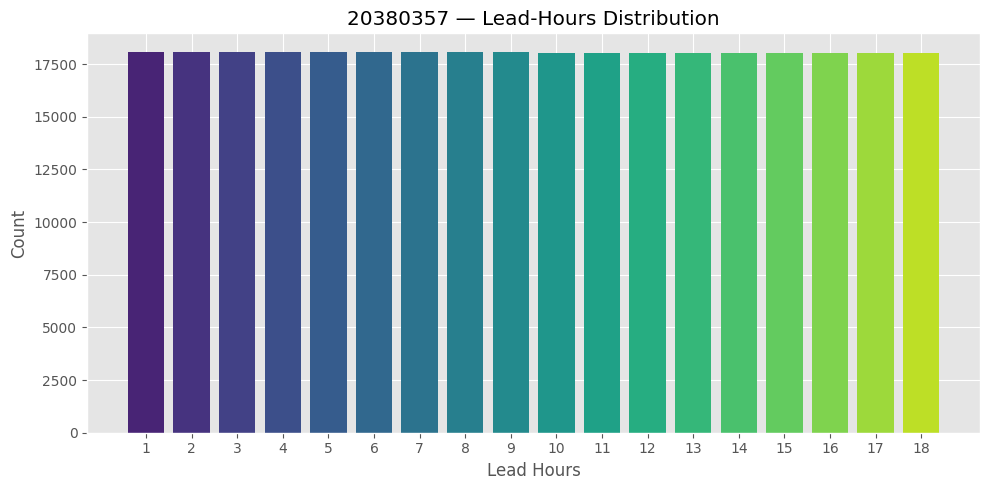

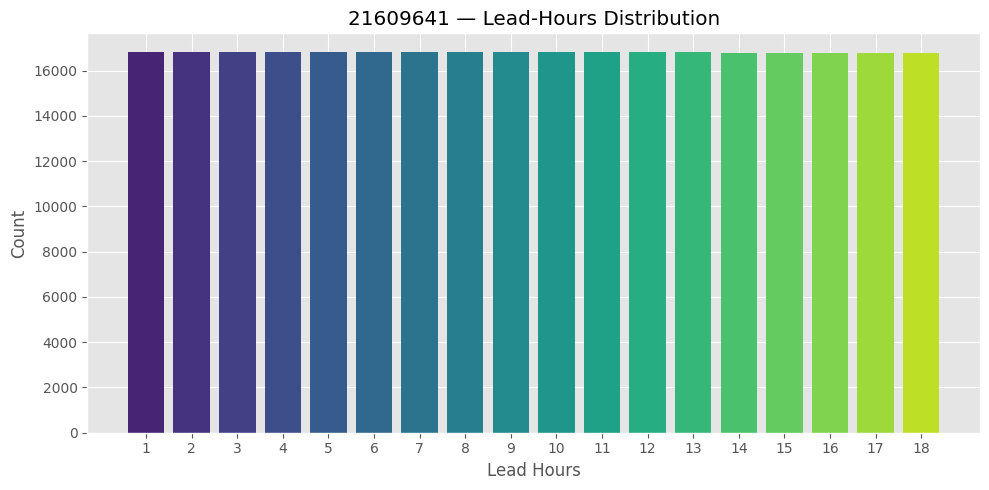

In [8]:
import matplotlib.pyplot as plt
from collections import Counter

plt.style.use('ggplot')


for station_name, df in aligned_data.items():
    counts = Counter(df['lead_hours'].values)
    hours  = sorted(counts.keys())
    values = [counts[h] for h in hours]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar([str(h) for h in hours], values,
           color=plt.cm.viridis(np.linspace(0.1, 0.9, len(hours))))
    ax.set_xlabel('Lead Hours')
    ax.set_ylabel('Count')
    ax.set_title(f'{station_name} — Lead-Hours Distribution')
    plt.tight_layout()
    plt.show()


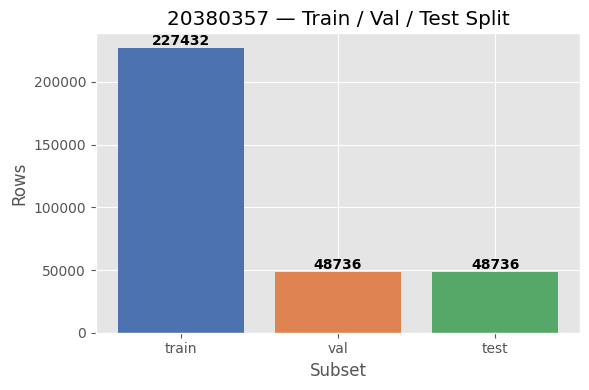

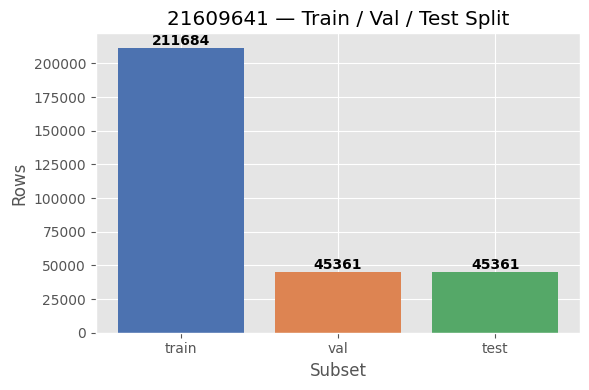

In [9]:
for station_name, s in splits.items():
    subset_labels = ['train', 'val', 'test']
    subset_sizes  = [
        s['X_train'].shape[0],
        s['X_val'].shape[0],
        s['X_test'].shape[0],
    ]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(subset_labels, subset_sizes,
                  color=['#4c72b0', '#dd8452', '#55a868'])
    ax.set_xlabel('Subset')
    ax.set_ylabel('Rows')
    ax.set_title(f'{station_name} — Train / Val / Test Split')

    for bar, val in zip(bars, subset_sizes):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
